In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
import numpy as np

In [2]:
# Number of qubits
n = 3

In [3]:
def Oracle(qc, target_state):
    """
    target_state: string like '1010' (MSB → LSB)
    """
    n = len(target_state)

    # Step 1: Apply X to qubits where bit = 0
    for i, bit in enumerate(reversed(target_state)):  # Qiskit ordering
        if bit == '0':
            qc.x(i)

    # Step 2: Multi-controlled Z
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Step 3: Uncompute
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)

In [4]:
# Define diffusion operator: H^n · (2|0⟩⟨0| - I) · H^n
def diffusion_operator(circuit):

    circuit.h(range(n))

    circuit.barrier()
    circuit.x(range(n))
    circuit.barrier()
    circuit.h(n - 1)
    circuit.mcx(list(range(n - 1)), n - 1)  # multi-controlled Z
    circuit.h(n - 1)
    circuit.barrier()
    circuit.x(range(n))

    circuit.barrier()
    circuit.h(range(n))

In [5]:
grover_circuit = QuantumCircuit(n)

grover_circuit.h(range(n))
grover_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 0), Qubit(QuantumRegister(3, 'q'), 1), Qubit(QuantumRegister(3, 'q'), 2)), clbits=())

In [6]:
grover_circuit.barrier()
Oracle(grover_circuit, '011')

In [7]:
grover_circuit.barrier()
grover_circuit.barrier()
diffusion_operator(grover_circuit)

In [8]:
grover_circuit.barrier()
Oracle(grover_circuit, '011')

In [9]:
grover_circuit.barrier()
grover_circuit.barrier()
diffusion_operator(grover_circuit)

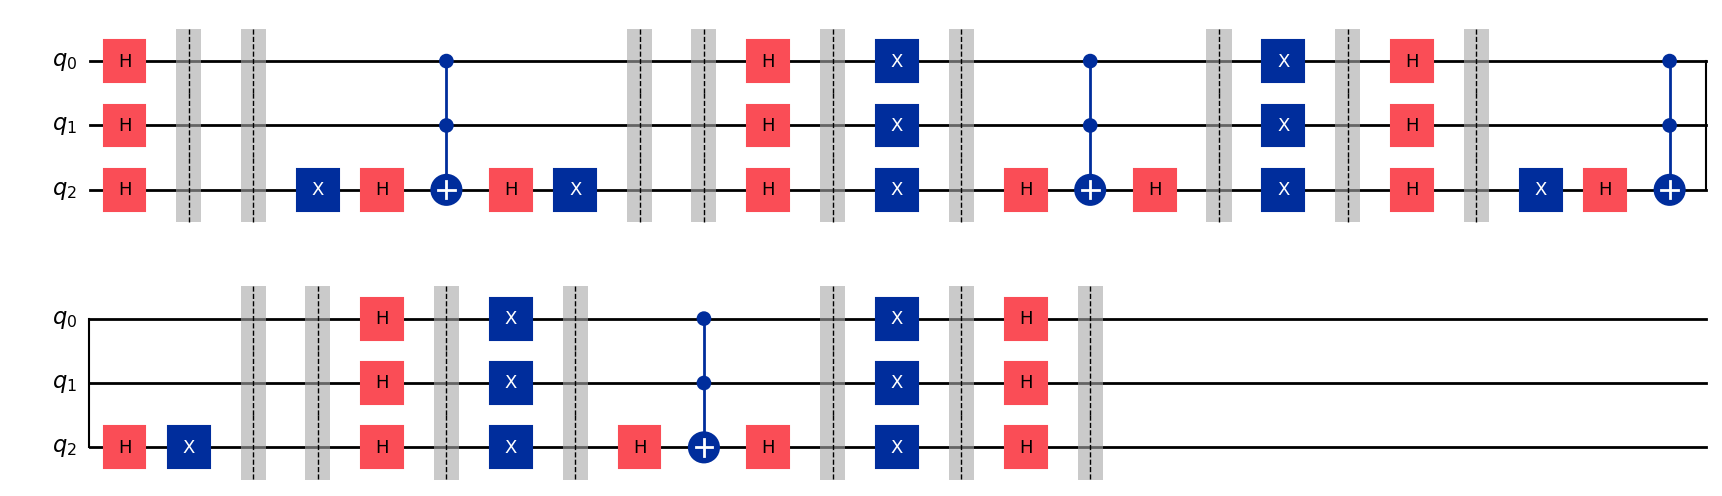

In [10]:
# Visualize the circuit
grover_circuit.barrier()
grover_circuit.draw('mpl')

In [11]:
state = Statevector(grover_circuit)
print(state)
state.draw('latex')  # Visual view of amplitudes

Statevector([-0.08838835+0.j, -0.08838835+0.j, -0.08838835+0.j,
              0.97227182+0.j, -0.08838835+0.j, -0.08838835+0.j,
             -0.08838835+0.j, -0.08838835+0.j],
            dims=(2, 2, 2))


<IPython.core.display.Latex object>

In [ ]:
from qiskit import __version__ as qiskit_version
from qiskit_aer import __version__ as aer_version
from platform import python_version

print('Qiskit Version:', qiskit_version)
print('Qiskit_Aer Version:', aer_version)
print('Python Version:', python_version())
print('2026 ©')